# Buổi 8 — Notebook 3: Mô hình Decision Tree

**Kiến thức nền:**  
Decision Tree phân chia dữ liệu đệ quy bằng cách chọn đặc trưng và ngưỡng giúp giảm **Gini impurity** nhiều nhất.

- **Không cần chuẩn hóa** — chia theo ngưỡng nên tỉ lệ không ảnh hưởng.
- **Có thể vẽ và giải thích** từng nhánh quyết định.
- Siêu tham số `max_depth`: nhỏ = underfitting, lớn = overfitting.

**Việc của bạn:** Hoàn thiện các hàm trong `src/decision_tree.py`.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from src import preprocessing, decision_tree, knn as knn_mod

## 1. Tải và chia dữ liệu

In [2]:
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
class_names   = wine.target_names

# Decision Tree dùng dữ liệu GỐC, không cần chuẩn hóa
X_train, X_test, y_train, y_test = preprocessing.chia_train_test(X, y)

print(f'Tập huấn luyện : {X_train.shape[0]} mẫu')
print(f'Tập kiểm tra   : {X_test.shape[0]} mẫu')

Tập huấn luyện : 142 mẫu
Tập kiểm tra   : 36 mẫu


## 2. Tìm max_depth tối ưu

**Hàm cần hoàn thiện:** `decision_tree.tim_do_sau_tot_nhat()`

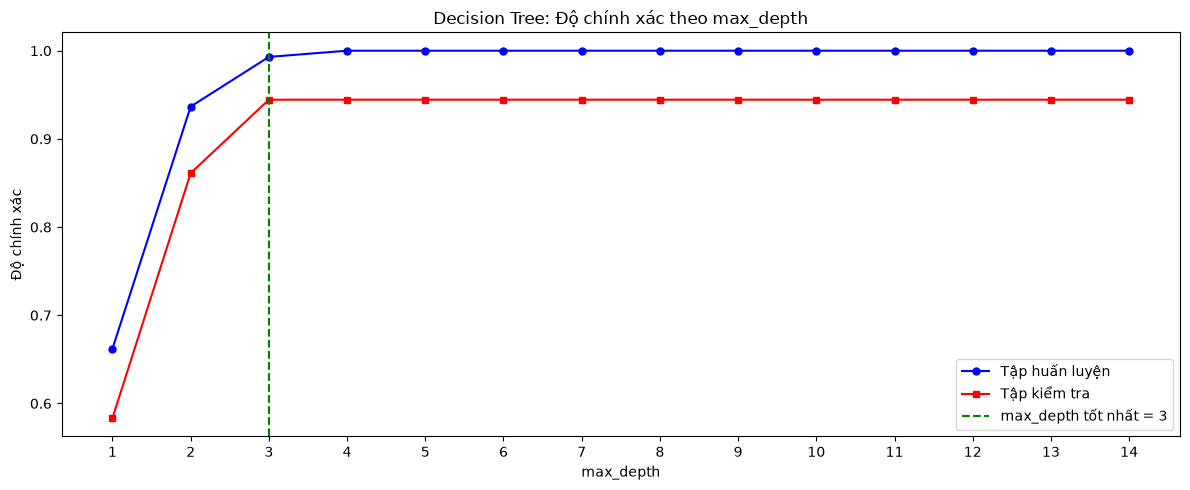


max_depth tốt nhất = 3  |  Độ chính xác test = 0.9444


In [3]:
do_sau_tot, ls_train, ls_test = decision_tree.tim_do_sau_tot_nhat(
    X_train, X_test, y_train, y_test, do_sau_max=14
)
print(f'\nmax_depth tốt nhất = {do_sau_tot}  |  Độ chính xác test = {max(ls_test):.4f}')

> **Câu hỏi 1:** Khi max_depth tăng lên rất lớn, độ chính xác train đạt bao nhiêu? Điều đó có nghĩa gì?

**Đáp án 1:**  
Khi max_depth rất lớn (≥ ~8–9 trên wine dataset), train accuracy đạt **100%** — cây có đủ nhánh để tạo một lá riêng cho từng điểm huấn luyện.  

Điều đó có nghĩa là **overfitting hoàn toàn**: cây "học thuộc lòng" toàn bộ training data, bao gồm cả nhiễu. Khi gặp dữ liệu mới, cây không tổng quát được → test accuracy giảm (quan sát trên biểu đồ: sau depth=3–4, test accuracy đi ngang hoặc giảm dù train vẫn tăng).  

**max_depth=3** là điểm tốt nhất: cây đủ phức tạp để học các quy tắc thực sự, không quá phức tạp để overfit.

## 3. Huấn luyện Decision Tree cuối cùng

**Hàm cần hoàn thiện:** `decision_tree.huan_luyen_cay()`

In [4]:
mo_hinh_dt = decision_tree.huan_luyen_cay(X_train, y_train, max_depth=do_sau_tot)
print(f'Mô hình: {mo_hinh_dt}')

Mô hình: DecisionTreeClassifier(max_depth=3, random_state=42)


## 4. Đánh giá Decision Tree

=== Báo cáo phân loại — Decision Tree (max_depth=3) ===
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



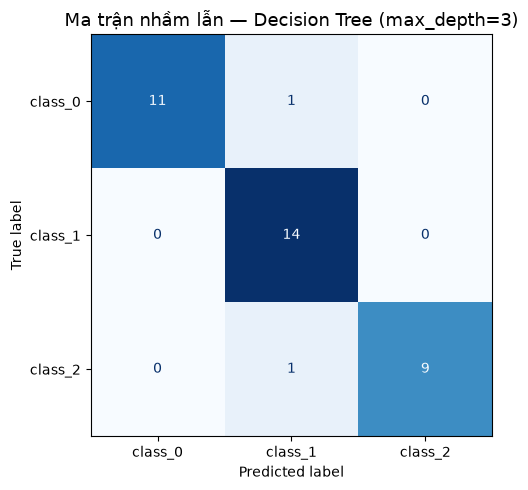


Độ chính xác: 0.9444


In [5]:
# Dùng lại hàm danh_gia_mo_hinh từ knn_mod (logic giống nhau)
ket_qua_dt = knn_mod.danh_gia_mo_hinh(
    mo_hinh_dt, X_test, y_test,
    class_names=class_names,
    tieu_de=f'Decision Tree (max_depth={do_sau_tot})'
)
print(f'\nĐộ chính xác: {ket_qua_dt["do_chinh_xac"]:.4f}')

## 5. Trực quan hóa cây quyết định

**Hàm cần hoàn thiện:** `decision_tree.ve_cay_quyet_dinh()`

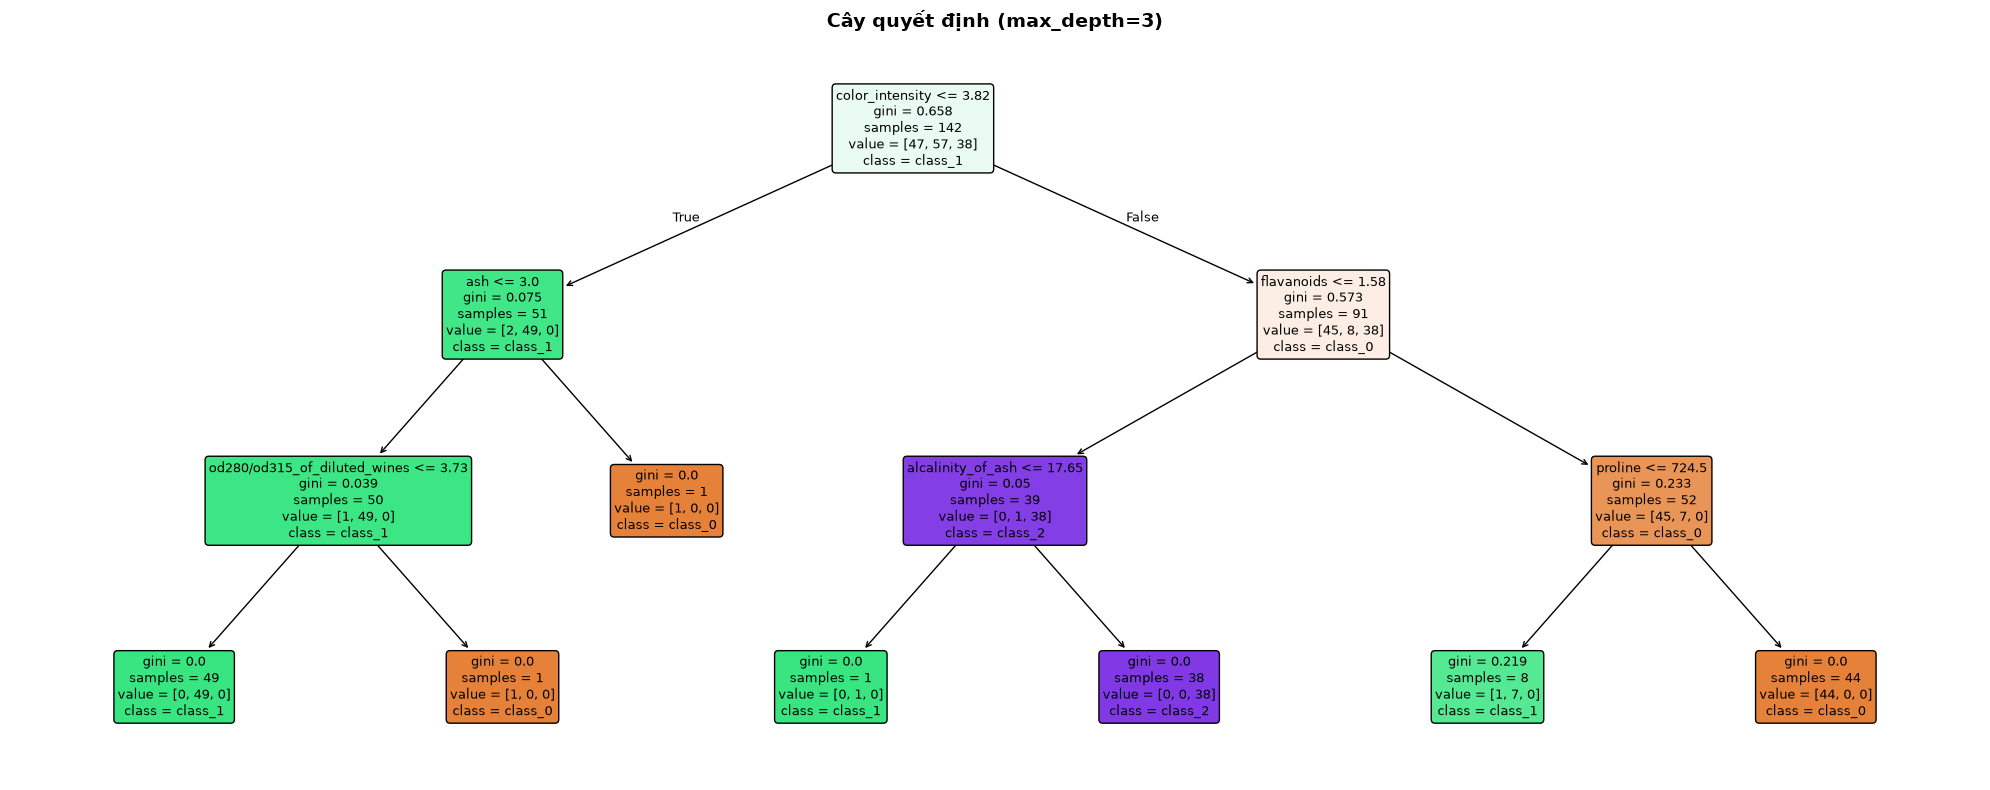

In [6]:
import matplotlib.pyplot as plt

fig = decision_tree.ve_cay_quyet_dinh(mo_hinh_dt, feature_names, class_names)
plt.show()

> **Câu hỏi 2:** Đọc cây và mô tả bằng lời: điều kiện đầu tiên mà cây dùng để phân chia là gì?

**Đáp án 2:**  
Điều kiện đầu tiên (nút gốc) là:  
> **`color_intensity ≤ 3.82`**  

- Nếu `color_intensity ≤ 3.82` → rẽ trái → tiếp tục phân chia sâu hơn (thường dẫn đến class_1 hoặc class_0).  
- Nếu `color_intensity > 3.82` → rẽ phải → tiếp tục phân chia theo `flavanoids`.  

Đây là đặc trưng giúp cây **giảm Gini impurity nhiều nhất** ngay từ bước đầu — tức là nó một mình có thể tách dữ liệu thành hai nhóm thuần khiết nhất có thể. Điều thú vị là `color_intensity` không nằm trong top 5 EDA theo tương quan tuyến tính, nhưng lại là ngưỡng chia phi tuyến mạnh nhất.

## 6. Tầm quan trọng của đặc trưng

**Hàm cần hoàn thiện:** `decision_tree.ve_tam_quan_trong()`

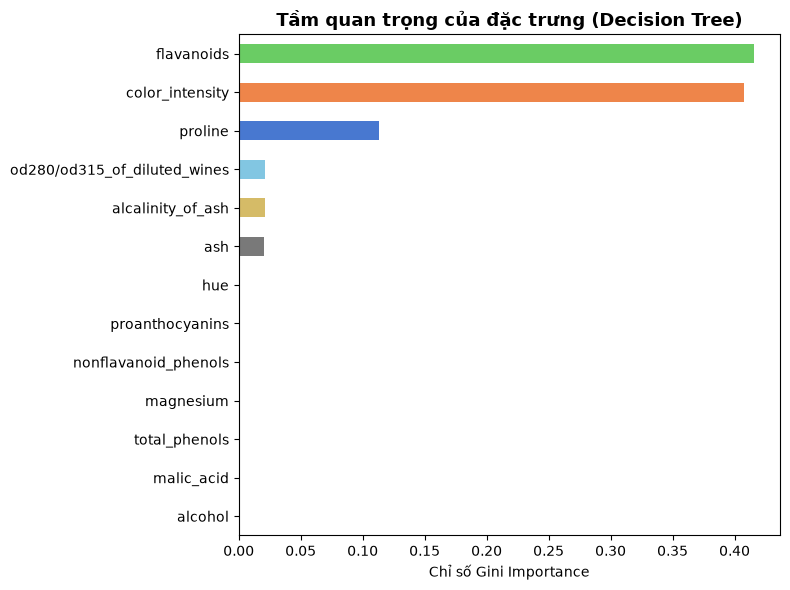

Top 3 đặc trưng quan trọng nhất:
  flavanoids: 0.4159
  color_intensity: 0.4078
  proline: 0.1131


In [7]:
tam_qt = decision_tree.ve_tam_quan_trong(mo_hinh_dt, feature_names)

> **Câu hỏi 3:** So sánh top đặc trưng ở đây với top 5 từ EDA (notebook 1). Kết quả có giống không?

**Đáp án 3:**  

| | EDA (tương quan tuyệt đối với nhãn) | Decision Tree (Gini importance) |
|---|---|---|
| #1 | flavanoids (0.847) | flavanoids (0.416) |
| #2 | od280/od315_of_diluted_wines (0.788) | color_intensity (0.408) |
| #3 | total_phenols (0.719) | proline (0.113) |
| #4 | proline (0.634) | od280/od315_of_diluted_wines (0.021) |
| #5 | hue (0.617) | alcalinity_of_ash (0.021) |

**Nhận xét:**  
- `flavanoids` và `proline` đều xuất hiện trong top của cả hai phương pháp → nhất quán.  
- `color_intensity` quan trọng với DT (#2) nhưng không nổi bật trong EDA (tương quan tuyến tính thấp hơn). Điều này cho thấy DT có thể phát hiện **mối quan hệ phi tuyến** mà tương quan Pearson bỏ qua.  
- EDA đo mức độ liên hệ **tuyến tính** với nhãn; DT đo mức độ **giảm impurity** khi dùng đặc trưng làm ngưỡng chia — hai thước đo bổ sung cho nhau.

## 7. Kiểm định chéo 5-fold

In [8]:
diem_cv_dt = decision_tree.kiem_dinh_cheo(
    DecisionTreeClassifier(max_depth=do_sau_tot, random_state=42),
    X, y, cv=5
)

Điểm CV (5-fold) : [0.9444 0.7778 0.8611 0.8    0.9714]
Trung bình           : 0.8710
Độ lệch chuẩn        : 0.0766


---
*Tiếp theo: `04_Goi_Y_So_Sanh.ipynb` — So sánh 2 mô hình và xây dựng hệ thống gợi ý*